In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
#Dataset Loading
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 348kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.85MB/s]


In [3]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
train_loader

# **Define Variational Autoencoder Model**

The VAE contains:

1. Encoder

2. Reparameterization Trick

3. Decoder

In [5]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()


    # Encoder
    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


    # Reparameterization Trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z


    # Decoder
    def decode(self, z):
        h = self.relu(self.fc2(z))
        reconstruction = self.sigmoid(self.fc3(h))
        return reconstruction


    # Forward Pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

# **Initialize Model and Optimizer**

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# **VAE Loss Function**
The total VAE loss is:

Total Loss = Reconstruction Loss + KL Divergence

Reconstruction Loss

Measures how well the decoder reconstructs the input.

KL Divergence

Forces latent distribution to be close to standard normal distribution.


In [7]:
def vae_loss(reconstructed_x, x, mu, logvar):

    # Reconstruction loss
    recon_loss = nn.functional.binary_cross_entropy(
        reconstructed_x,
        x,
        reduction='sum'
    )

    # KL Divergence
    kl_div = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + kl_div

    return total_loss, recon_loss, kl_div

# **Training Loop**

In [9]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        # Forward pass
        reconstructed, mu, logvar = model(data)

        # Compute losses
        loss, recon_loss, kl_loss = vae_loss(
            reconstructed,
            data,
            mu,
            logvar
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()


    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Reconstruction Loss: {total_recon:.2f}")
    print(f"KL Divergence Loss: {total_kl:.2f}")
    print("-------------")

Epoch [1/20]
Total Loss: 6860685.41
Reconstruction Loss: 5419925.84
KL Divergence Loss: 1440759.57
-------------
Epoch [2/20]
Total Loss: 6686484.78
Reconstruction Loss: 5213914.75
KL Divergence Loss: 1472570.03
-------------
Epoch [3/20]
Total Loss: 6589647.04
Reconstruction Loss: 5099462.26
KL Divergence Loss: 1490184.78
-------------
Epoch [4/20]
Total Loss: 6517501.90
Reconstruction Loss: 5017340.45
KL Divergence Loss: 1500161.44
-------------
Epoch [5/20]
Total Loss: 6470447.21
Reconstruction Loss: 4966063.86
KL Divergence Loss: 1504383.34
-------------
Epoch [6/20]
Total Loss: 6432491.21
Reconstruction Loss: 4921236.78
KL Divergence Loss: 1511254.43
-------------
Epoch [7/20]
Total Loss: 6403148.48
Reconstruction Loss: 4888169.42
KL Divergence Loss: 1514979.06
-------------
Epoch [8/20]
Total Loss: 6382548.16
Reconstruction Loss: 4863197.39
KL Divergence Loss: 1519350.78
-------------
Epoch [9/20]
Total Loss: 6362105.52
Reconstruction Loss: 4841308.87
KL Divergence Loss: 1520796.

# **Visualization of  Reconstructed Images**

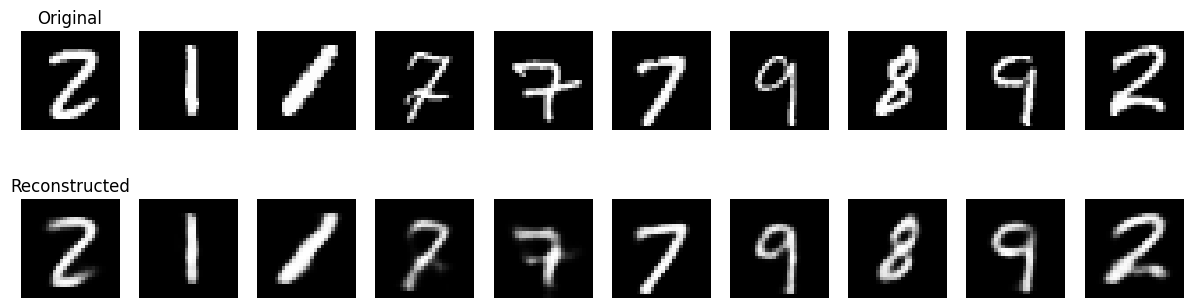

In [10]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, loader, device):

    model.eval()

    with torch.no_grad():
        data, _ = next(iter(loader))
        data = data.view(-1, 784).to(device)

        reconstructed, _, _ = model(data)

        data = data.cpu().view(-1,1,28,28)
        reconstructed = reconstructed.cpu().view(-1,1,28,28)

        fig, axes = plt.subplots(2, 10, figsize=(15,4))

        for i in range(10):
            # Original
            axes[0,i].imshow(data[i][0], cmap="gray")
            axes[0,i].axis("off")

            # Reconstructed
            axes[1,i].imshow(reconstructed[i][0], cmap="gray")
            axes[1,i].axis("off")

        axes[0,0].set_title("Original")
        axes[1,0].set_title("Reconstructed")

        plt.show()

visualize_reconstruction(model, train_loader, device)

# **Generation of New Digits from Latent Space**

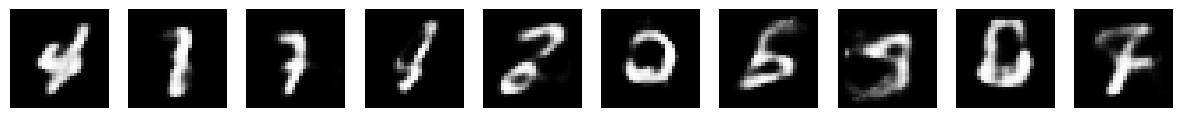

In [11]:
def generate_digits(model, device, num_samples=10):

    model.eval()

    with torch.no_grad():

        z = torch.randn(num_samples, 20).to(device)

        generated = model.decode(z)
        generated = generated.cpu().view(-1,1,28,28)

        fig, axes = plt.subplots(1, num_samples, figsize=(15,2))

        for i in range(num_samples):
            axes[i].imshow(generated[i][0], cmap='gray')
            axes[i].axis('off')

        plt.show()

generate_digits(model, device)

# **Interpretation**

After training the Variational Autoencoder on the MNIST dataset, I observed that the model was able to learn meaningful representations of handwritten digits. In this implementation, the encoder first transforms the input images into latent space parameters, specifically the mean (μ) and log variance (log(σ²)). These parameters describe a probability distribution in the latent space instead of a single fixed representation. Using the reparameterization trick, a latent vector z is sampled from this distribution, which allows the model to perform stochastic sampling while still enabling gradient-based optimization during training.

The decoder then takes the sampled latent vector and attempts to reconstruct the original image. During training, the model minimizes a combined loss consisting of reconstruction loss and KL divergence loss. The reconstruction loss measures how closely the reconstructed images match the original MNIST images, while the KL divergence ensures that the learned latent space distribution remains close to a standard normal distribution.

As the training process progresses, the overall loss decreases, which indicates that the model is learning to represent the input data effectively. The reconstructed images produced by the decoder become increasingly similar to the original images, demonstrating that the VAE successfully captures the important features of the handwritten digits. This shows that the model is capable of compressing high-dimensional image data into a lower-dimensional latent representation while still retaining essential information needed for reconstruction.

Overall, the implemented Variational Autoencoder performs well on the MNIST dataset by learning a structured latent space and producing meaningful reconstructions. This also indicates that the model can potentially generate new digit images by sampling from the learned latent space distribution.